# Online Retail — Veri Bilimi Projesi

Bu proje, bir e-ticaret şirketinin 2010–2011 yılları arasındaki işlem verilerini kullanarak
müşteri davranışını anlamayı ve iş kararlarını destekleyecek içgörüler üretmeyi hedeflemektedir.

**Veri Seti:** [UCI Online Retail Dataset](https://www.kaggle.com/datasets/vijayuv/onlineretail)  
**Kayıt Sayısı:** ~541.000 işlem | **Kapsam:** 38 ülke | **Dönem:** Aralık 2010 – Aralık 2011

---

## Araştırma Soruları

**S1 — Ülke ve Zaman Bazlı Satış Örüntüleri**  
Toplam gelir ülke bazında nasıl dağılıyor? Aylık trendlerde mevsimsellik var mı?
Sipariş yoğunluğu haftanın günlerine ve günün saatlerine göre nasıl şekilleniyor?

**S2 — Müşteri Segmentasyonu**  
RFM (Recency, Frequency, Monetary) boyutlarında müşteriler nasıl dağılıyor?
K-Means kümeleme ile anlamlı müşteri segmentleri (High-Value, Loyal, At-Risk, Dormant)
oluşturulabilir mi?

**S3 — Birlikte Satın Alma Analizi**  
Aynı fatura içinde hangi ürünler en sık birlikte satın alınıyor?
Frekans tabanlı sepet analizi ile çapraz satış fırsatları tespit edilebilir mi?

---

## İş Akışı

1. Veri Yükleme & Keşif  
2. Veri Temizleme & Özellik Türetme  
3. S1 — Keşifsel Veri Analizi (EDA)  
4. S2 — RFM Analizi & Müşteri Segmentasyonu  
5. S3 — Sepet Analizi  
6. Sonuçlar & Öneriler

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [25]:
# sns.set_theme evrensel tercih edilen yöntemdir:
# - plt.style.use('seaborn-v0_8') Matplotlib sürümüne göre hata verebilir
# - sns.set_theme hem Seaborn hem Matplotlib ayarlarını güvenli şekilde yapar
sns.set_theme(style='whitegrid')

In [26]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

In [27]:
print("=" * 50)
print("VERİ SETİ GENEL BİLGİLERİ")
print("=" * 50)
print(f"\nSatır sayısı : {df.shape[0]:,}")
print(f"Sütun sayısı : {df.shape[1]}")
print(f"\nSütunlar: {list(df.columns)}")
print("\n--- İlk 5 Satır ---")
print(df.head())
print("\n--- Veri Tipleri ve Null Değerler ---")
print(df.info())
print("\n--- Temel İstatistikler ---")
print(df.describe())

VERİ SETİ GENEL BİLGİLERİ

Satır sayısı : 541,909
Sütun sayısı : 8

Sütunlar: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

--- İlk 5 Satır ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

--- Ve

## Veri Temizleme

In [28]:
# ── 0. Ham veri boyutu ──
print(f"Ham veri: {df.shape[0]:,} satır | {df.shape[1]} sütun")

# ── 1. İptal siparişleri sil (InvoiceNo 'C' ile başlayanlar) ──
mask_cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
n_cancelled    = mask_cancelled.sum()
df_clean       = df[~mask_cancelled].copy()
print(f"İptal sipariş silindi: {n_cancelled:,} → kalan: {df_clean.shape[0]:,}")

# ── 2. Negatif / sıfır Quantity sil ──
mask_qty = df_clean['Quantity'] <= 0
n_qty    = mask_qty.sum()
df_clean = df_clean[~mask_qty].copy()
print(f"Quantity ≤ 0 silindi: {n_qty:,} → kalan: {df_clean.shape[0]:,}")

# ── 3. Negatif / sıfır UnitPrice sil ──
mask_price = df_clean['UnitPrice'] <= 0
n_price    = mask_price.sum()
df_clean   = df_clean[~mask_price].copy()
print(f"UnitPrice ≤ 0 silindi: {n_price:,} → kalan: {df_clean.shape[0]:,}")

# ── 4. Eksik CustomerID satırlarını sil ──
# Hedef müşteri bazlı analiz olduğu için kimliği bilinmeyen satırlar kullanılamaz.
# Null'lar rastgele dağılmış olduğundan silmek bias yaratmaz.
n_null_cid = df_clean['CustomerID'].isna().sum()
df_clean   = df_clean.dropna(subset=['CustomerID']).copy()
print(f"CustomerID NaN silindi: {n_null_cid:,} → kalan: {df_clean.shape[0]:,}")

# ── 5. Tip dönüşümleri ──
df_clean['CustomerID']  = df_clean['CustomerID'].astype(int).astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceNo']   = df_clean['InvoiceNo'].astype(str)

# ── 6. Türetilmiş sütun: TotalPrice ──
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# ── Özet ──
total_removed = df.shape[0] - df_clean.shape[0]
print(f"\nToplam silinen: {total_removed:,} (%{total_removed / df.shape[0] * 100:.1f})")
print(f"Temiz veri    : {df_clean.shape[0]:,} satır")

Ham veri: 541,909 satır | 8 sütun
İptal sipariş silindi: 9,288 → kalan: 532,621
Quantity ≤ 0 silindi: 1,336 → kalan: 531,285
UnitPrice ≤ 0 silindi: 1,181 → kalan: 530,104
CustomerID NaN silindi: 132,220 → kalan: 397,884

Toplam silinen: 144,025 (%26.6)
Temiz veri    : 397,884 satır


### Kalan Null Değerler

In [29]:
print(df_clean.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


### Temiz Veriden Örnek

In [30]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Veri Temizleme - Tarih Özellikleri & Aykırı Değer Yönetimi

In [31]:
# ── Tarih dönüşümü (bir önceki adımda yapıldıysa bu satırı atla) ──
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Tarih tabanlı yeni özellikler ──
df_clean['Year']       = df_clean['InvoiceDate'].dt.year
df_clean['Month']      = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth']  = df_clean['InvoiceDate'].dt.to_period('M')   # ör. 2011-03
df_clean['DayOfWeek']  = df_clean['InvoiceDate'].dt.dayofweek        # 0=Pazartesi, 6=Pazar
df_clean['DayName']    = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour']       = df_clean['InvoiceDate'].dt.hour

print("Yeni sütunlar eklendi:")
print(df_clean[['InvoiceDate','Year','Month','YearMonth','DayOfWeek','DayName','Hour']].head())

Yeni sütunlar eklendi:
          InvoiceDate  Year  Month YearMonth  DayOfWeek    DayName  Hour
0 2010-12-01 08:26:00  2010     12   2010-12          2  Wednesday     8
1 2010-12-01 08:26:00  2010     12   2010-12          2  Wednesday     8
2 2010-12-01 08:26:00  2010     12   2010-12          2  Wednesday     8
3 2010-12-01 08:26:00  2010     12   2010-12          2  Wednesday     8
4 2010-12-01 08:26:00  2010     12   2010-12          2  Wednesday     8


### Aykırı Değer Yönetimi — IQR Yöntemi

IQR = Q3 - Q1 olarak tanımlanır.  
Alt sınır: Q1 - 1.5 × IQR  
Üst sınır: Q3 + 1.5 × IQR  

Bu sınırların dışındaki değerleri **silmek** yerine **baskılıyoruz (capping/winsorizing)** çünkü:
- Gerçek bir müşteri 500 adet ürün de alabilir, bu veriyi kaybetmek istemeyiz
- Baskılama, uç değerleri sınıra çeker; gözlem sayısı korunur
- Silme tercih edilirse özellikle küçük veri setlerinde ciddi veri kaybı olur

In [32]:
def iqr_cap(series, factor=1.5):
    """Verilen serinin IQR sınırlarını hesaplar, aykırı değerleri baskılar."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    capped = series.clip(lower=lower, upper=upper)
    n_outliers = ((series < lower) | (series > upper)).sum()
    return capped, lower, upper, n_outliers


# ── Quantity ──
df_clean['Quantity'], q_lower, q_upper, q_out = iqr_cap(df_clean['Quantity'])

print("Quantity")
print(f"  Sınırlar : [{q_lower:.2f}, {q_upper:.2f}]")
print(f"  Baskılanan değer sayısı: {q_out}")

# ── UnitPrice ──
df_clean['UnitPrice'], p_lower, p_upper, p_out = iqr_cap(df_clean['UnitPrice'])

print("\nUnitPrice")
print(f"  Sınırlar : [{p_lower:.2f}, {p_upper:.2f}]")
print(f"  Baskılanan değer sayısı: {p_out}")

# ── TotalPrice'ı baskılama sonrası güncelle ──
# Quantity veya UnitPrice değiştiği için TotalPrice yeniden hesaplanmalı
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("\nGüncellenen TotalPrice istatistikleri:")
print(df_clean['TotalPrice'].describe().round(2))

Quantity
  Sınırlar : [-13.00, 27.00]
  Baskılanan değer sayısı: 25647

UnitPrice
  Sınırlar : [-2.50, 7.50]
  Baskılanan değer sayısı: 34356

Güncellenen TotalPrice istatistikleri:
count    397884.00
mean         15.03
std          17.59
min           0.00
25%           4.68
50%          10.50
75%          17.70
max         202.50
Name: TotalPrice, dtype: float64


### Aykırı Değer Görselleştirmesi — Öncesi / Sonrası

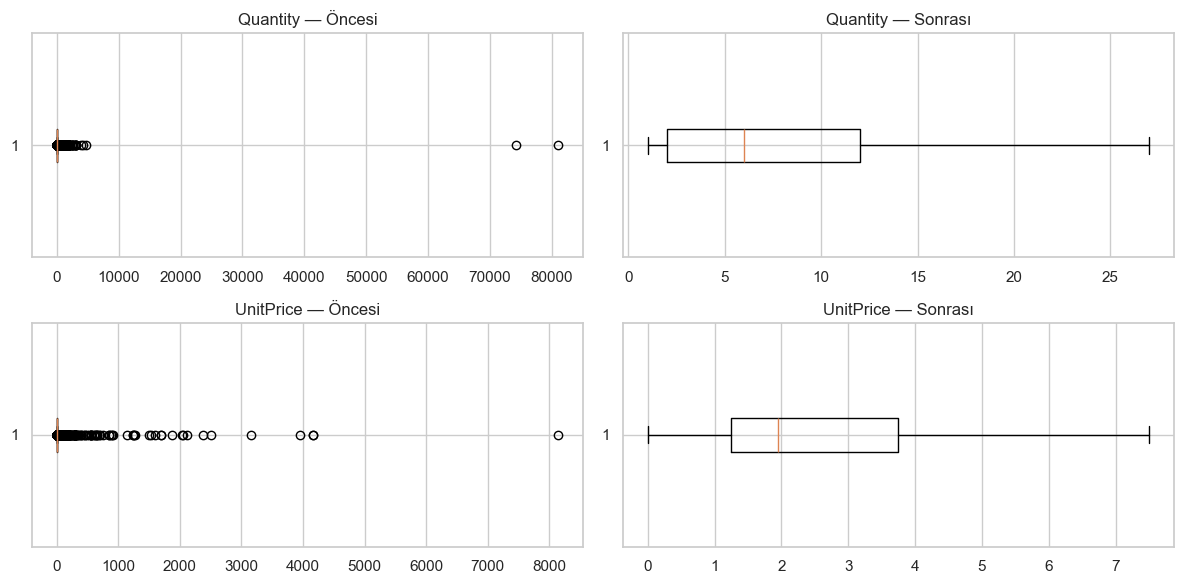

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Baskılama öncesi orijinal değerlere erişmek için ham veriyi tekrar okuyup filtreleyelim
df_ref = df[
    (~df['InvoiceNo'].astype(str).str.startswith('C')) &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (df['CustomerID'].notna())
].copy()

axes[0, 0].boxplot(df_ref['Quantity'].dropna(), vert=False)
axes[0, 0].set_title('Quantity — Öncesi')

axes[0, 1].boxplot(df_clean['Quantity'], vert=False)
axes[0, 1].set_title('Quantity — Sonrası')

axes[1, 0].boxplot(df_ref['UnitPrice'].dropna(), vert=False)
axes[1, 0].set_title('UnitPrice — Öncesi')

axes[1, 1].boxplot(df_clean['UnitPrice'], vert=False)
axes[1, 1].set_title('UnitPrice — Sonrası')

plt.tight_layout()
plt.show()

### S1.1 — Ülke Bazlı Ciro (UK Hariç) & Aylık Ciro Trendi (Aralık 2011 hariç)

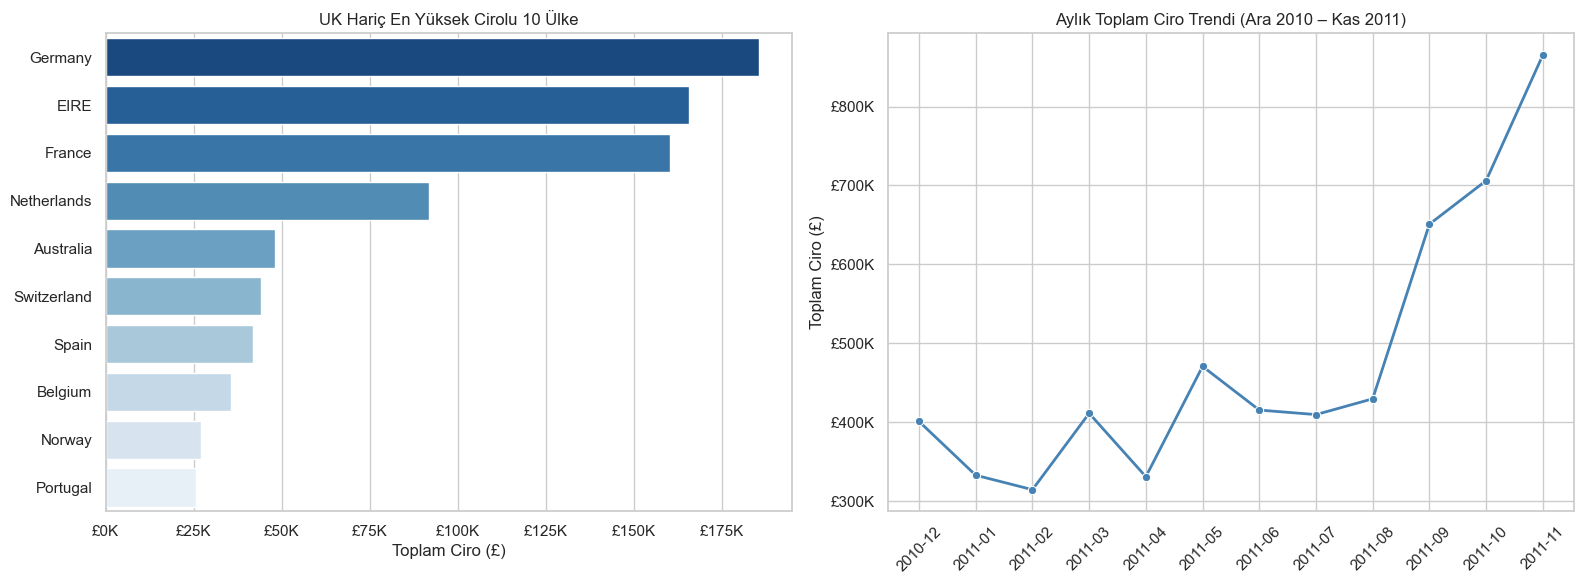

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 1. Ülke bazlı ciro (UK hariç, ilk 10) ──
country_revenue = (
    df_clean[df_clean['Country'] != 'United Kingdom']
    .groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=country_revenue,
    x='TotalPrice',
    y='Country',
    ax=axes[0],
    hue='Country',
    palette='Blues_r',
    legend=False
)
axes[0].set_title('UK Hariç En Yüksek Cirolu 10 Ülke')
axes[0].set_xlabel('Toplam Ciro (£)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# ── 2. Aylık ciro trendi (Aralık 2011 hariç) ──
monthly_revenue = (
    df_clean[df_clean['YearMonth'] != pd.Period('2011-12', 'M')]
    .groupby('YearMonth')['TotalPrice']
    .sum()
    .reset_index()
)
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

sns.lineplot(
    data=monthly_revenue,
    x='YearMonth',
    y='TotalPrice',
    ax=axes[1],
    marker='o',
    color='steelblue',
    linewidth=2
)
axes[1].set_title('Aylık Toplam Ciro Trendi (Ara 2010 – Kas 2011)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Toplam Ciro (£)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### S1.2 — Sipariş Yoğunluğu: Gün & Saat Isı Haritası

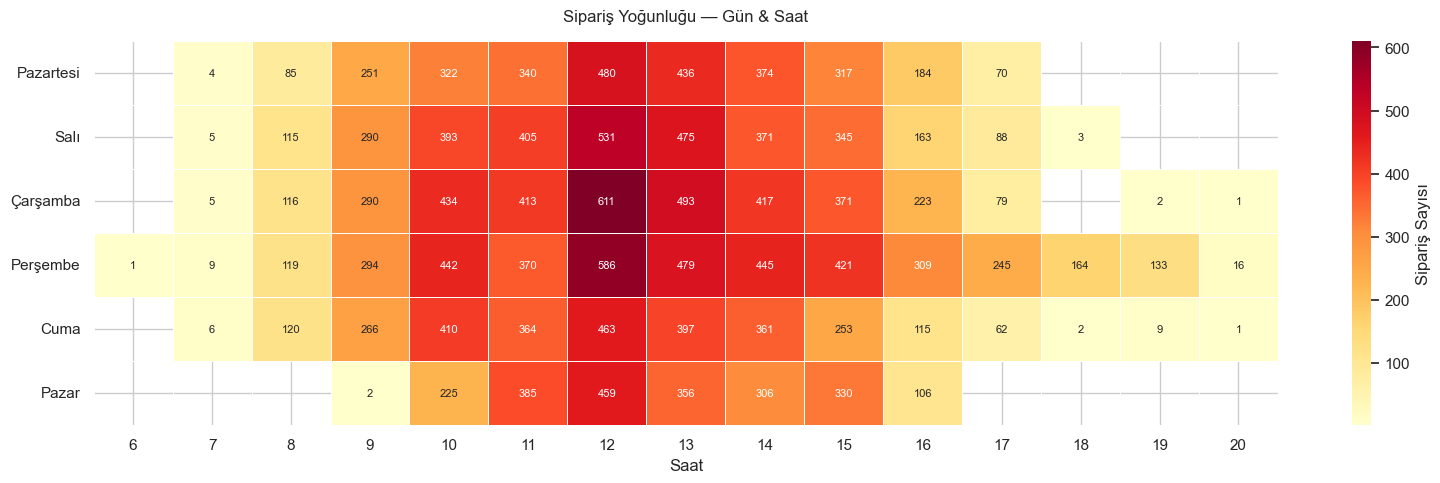

In [35]:
# Gün x Saat pivot tablosu — sipariş sayısı (benzersiz InvoiceNo)
heatmap_data = (
    df_clean.groupby(['DayOfWeek', 'Hour'])['InvoiceNo']
    .nunique()
    .reset_index()
    .pivot(index='DayOfWeek', columns='Hour', values='InvoiceNo')
)

# Gün indeksini okunabilir etikete çevir
day_labels = ['Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma', 'Cumartesi', 'Pazar']
heatmap_data.index = [day_labels[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Sipariş Sayısı'}
)

ax.set_title('Sipariş Yoğunluğu — Gün & Saat', pad=14)
ax.set_xlabel('Saat')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### S1.3 — Saatlik Sipariş Dağılımı: Histogram

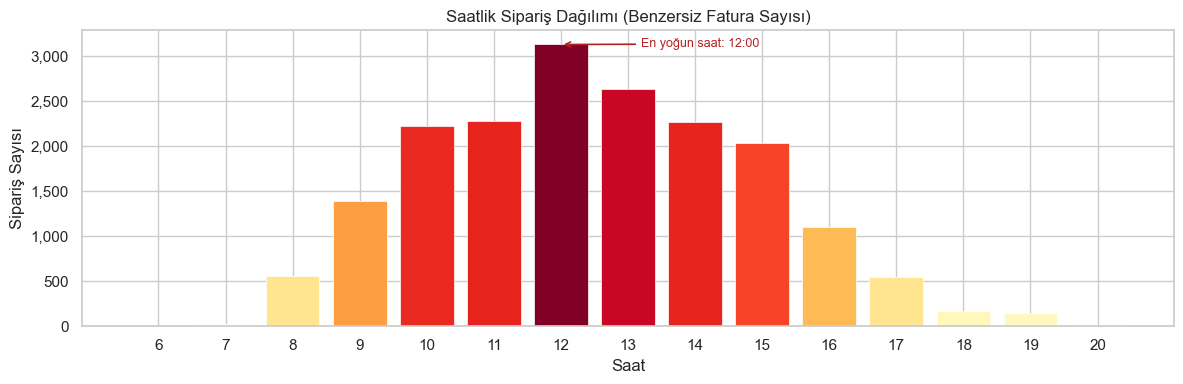

In [36]:
# Günün hangi saatinde kaç benzersiz sipariş verildiğini gösterir.
# Histogram, sürekli bir değişkenin (saat) frekans dağılımını ortaya koyar.
# Bu grafik EDA'da görselleştirme çeşitliliğini tamamlar ve
# ısı haritasındaki saat örüntüsünü tek eksen üzerinde doğrular.

hourly_orders = (
    df_clean.groupby('Hour')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'SiparisAdedi'})
)

fig, ax = plt.subplots(figsize=(12, 4))

# Her saati ayrı bir çubuk olarak göster; renk yoğunluğu sipariş miktarını yansıtır
bars = ax.bar(
    hourly_orders['Hour'],
    hourly_orders['SiparisAdedi'],
    color=plt.cm.YlOrRd(hourly_orders['SiparisAdedi'] / hourly_orders['SiparisAdedi'].max()),
    edgecolor='white',
    linewidth=0.5
)

# En yoğun saati etiketle
peak_hour = hourly_orders.loc[hourly_orders['SiparisAdedi'].idxmax(), 'Hour']
peak_val  = hourly_orders['SiparisAdedi'].max()
ax.annotate(
    f'En yoğun saat: {peak_hour}:00',
    xy=(peak_hour, peak_val),
    xytext=(peak_hour + 1.2, peak_val - 30),
    fontsize=9,
    color='firebrick',
    arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.2)
)

ax.set_title('Saatlik Sipariş Dağılımı (Benzersiz Fatura Sayısı)')
ax.set_xlabel('Saat')
ax.set_ylabel('Sipariş Sayısı')
ax.set_xticks(hourly_orders['Hour'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## S2 — Müşteri Segmentasyonu
### S2.1 — RFM Tablosu Oluşturma

In [37]:
# Analizin 'bugün'ü: veri setindeki en son tarihten 1 gün sonrası
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_df = (
    df_clean.groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('InvoiceNo',   'nunique'),
        Monetary  = ('TotalPrice',  'sum')
    )
    .reset_index()
)

print(f"Snapshot tarihi : {snapshot_date.date()}")
print(f"Müşteri sayısı  : {rfm_df.shape[0]:,}")
print()
print(rfm_df.describe().round(2))

Snapshot tarihi : 2011-12-10
Müşteri sayısı  : 4,338

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    1378.17
std     100.01       7.70    3505.84
min       1.00       1.00       3.75
25%      18.00       1.00     261.12
50%      51.00       2.00     580.26
75%     142.00       5.00    1413.60
max     374.00     209.00  113703.10


### S2.2 — Log Dönüşümü, Ölçekleme & Korelasyon Matrisi

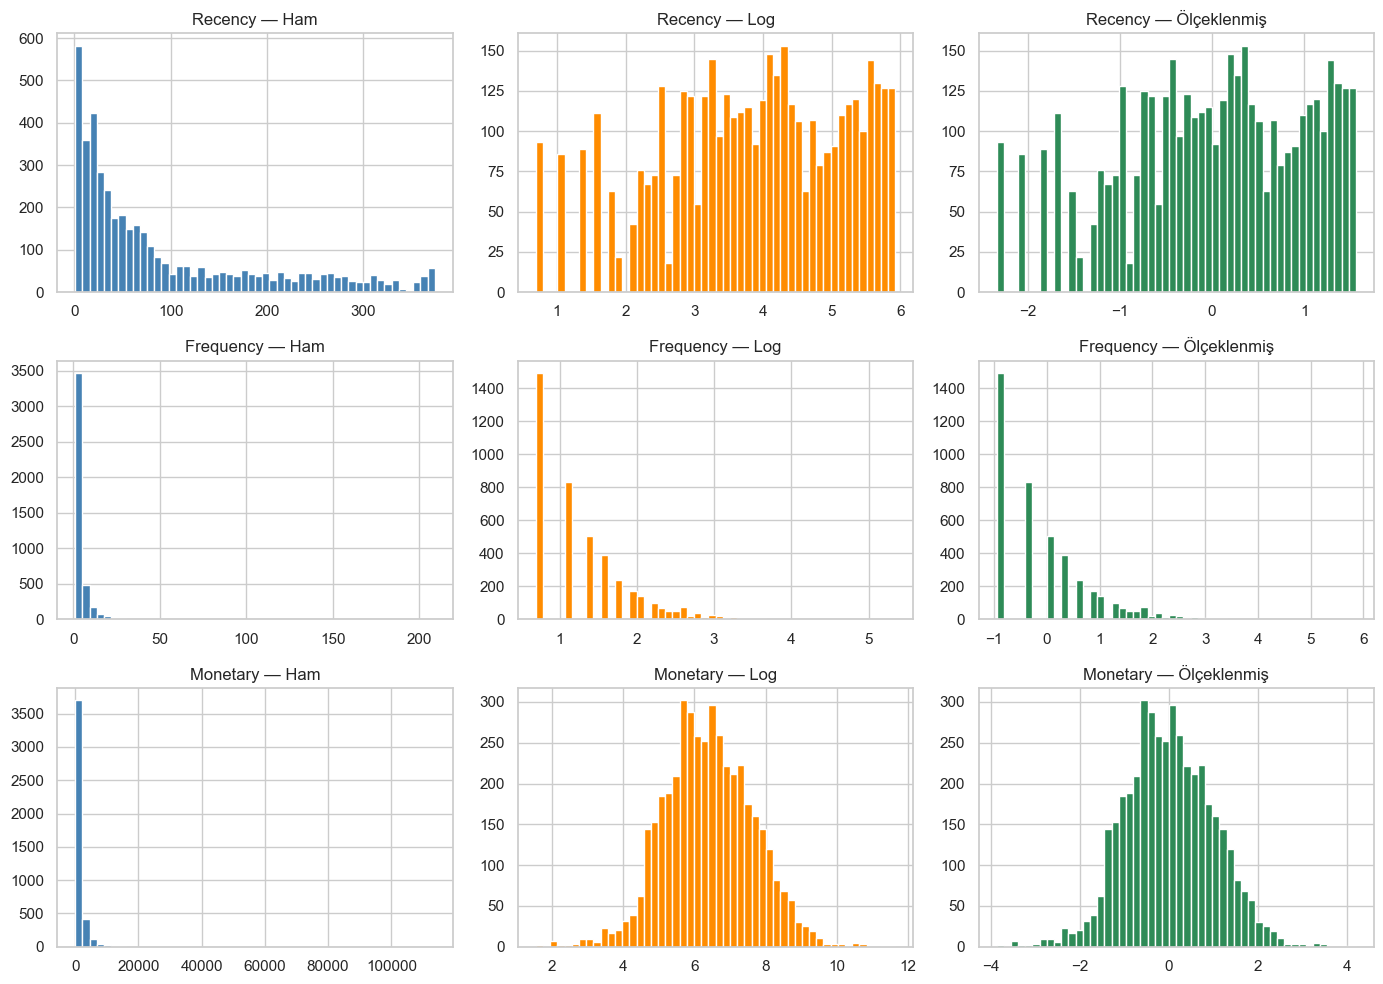

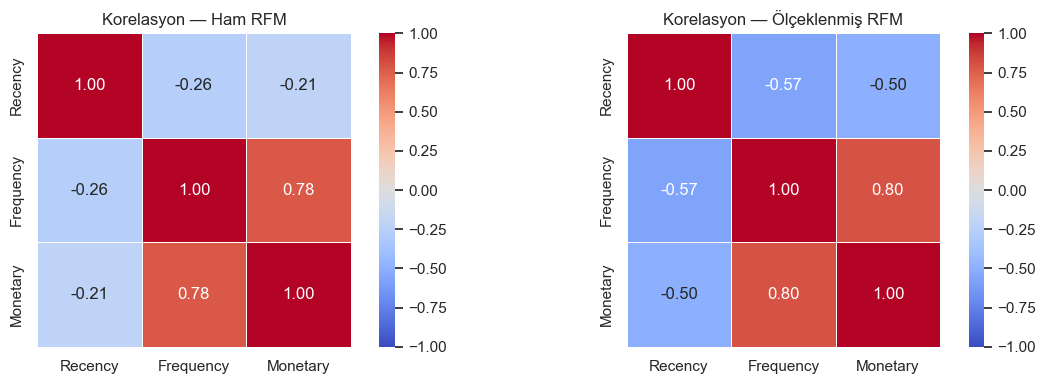

In [38]:
# ── Log dönüşümü (sağa çarpıklığı gider) ──
rfm_log = rfm_df[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

# ── StandardScaler ile ölçekleme ──
scaler   = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# ── Dağılım karşılaştırması: ham vs log vs ölçeklenmiş ──
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
cols = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(cols):
    rfm_df[col].hist(ax=axes[i, 0], bins=50, color='steelblue')
    axes[i, 0].set_title(f'{col} — Ham')

    rfm_log[col].hist(ax=axes[i, 1], bins=50, color='darkorange')
    axes[i, 1].set_title(f'{col} — Log')

    rfm_scaled[col].hist(ax=axes[i, 2], bins=50, color='seagreen')
    axes[i, 2].set_title(f'{col} — Ölçeklenmiş')

plt.tight_layout()
plt.show()

# ── Korelasyon matrisi ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    rfm_df[cols].corr(),
    ax=axes[0],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
axes[0].set_title('Korelasyon — Ham RFM')

sns.heatmap(
    rfm_scaled[cols].corr(),
    ax=axes[1],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
axes[1].set_title('Korelasyon — Ölçeklenmiş RFM')

plt.tight_layout()
plt.show()

### S2.3 — Optimal Küme Sayısı: Elbow Yöntemi

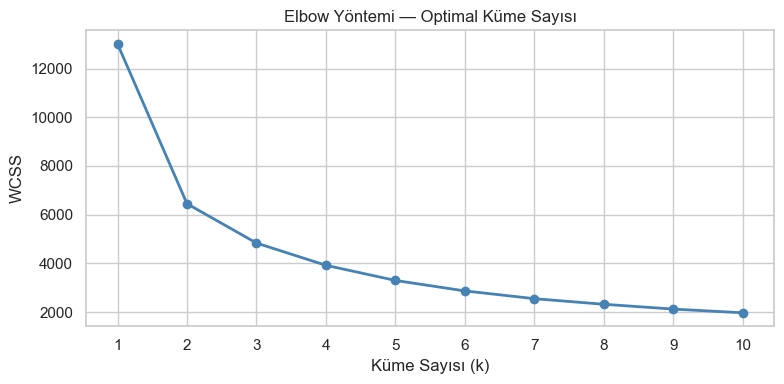

In [39]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# ── Elbow grafiği ──
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Yöntemi — Optimal Küme Sayısı')
ax.set_xlabel('Küme Sayısı (k)')
ax.set_ylabel('WCSS')
ax.set_xticks(k_range)

plt.tight_layout()
plt.show()

### S2.4 — K-Means Modeli & Küme Dağılımları

#### Neden k = 4?

Elbow grafiğinde WCSS (küme içi kareler toplamı) değeri k arttıkça düşmektedir;
ancak bu düşüşün **belirgin biçimde yavaşladığı nokta** modelin optimum küme sayısını gösterir.

Grafikte incelendiğinde:
- k=1 → k=2 ve k=2 → k=3 arasında WCSS hızlı düşmektedir
- **k=3 → k=4** geçişinde düşüş hâlâ anlamlıdır
- k=4 → k=5 ve sonrasında eğri belirgin şekilde yataylaşmaktadır

Bu nedenle **k = 4** dirsek (elbow) noktası olarak seçilmiştir.
4 segment, e-ticaret bağlamında yorumlanabilir ve birbirinden ayrışan
müşteri profilleri (High-Value, Loyal, At-Risk, Dormant) üretmektedir.

In [40]:
# ── K-Means modeli ──
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# ── Küme özeti ──
print(rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))
print()
print(rfm_df['Cluster'].value_counts().sort_index().rename('Müşteri Sayısı'))

         Recency  Frequency  Monetary
Cluster                              
0          18.36       2.09    469.64
1         183.17       1.33    279.88
2          69.36       4.08   1363.23
3          11.96      13.74   4926.84

Cluster
0     819
1    1610
2    1196
3     713
Name: Müşteri Sayısı, dtype: int64


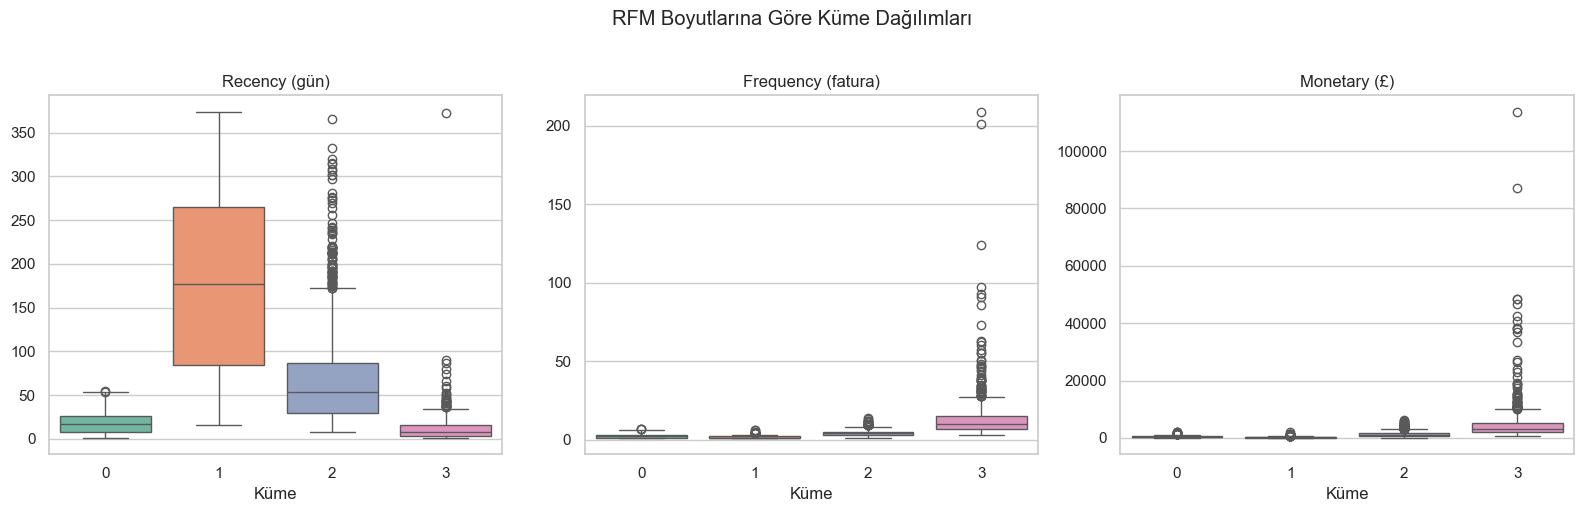

In [41]:
# ── Boxplot: her RFM boyutu için küme dağılımı ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols   = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency (gün)', 'Frequency (fatura)', 'Monetary (£)']

for i, (col, title) in enumerate(zip(cols, titles)):
    sns.boxplot(
        data=rfm_df,
        x='Cluster',
        y=col,
        ax=axes[i],
        hue='Cluster',
        palette='Set2',
        legend=False
    )
    axes[i].set_title(title)
    axes[i].set_xlabel('Küme')
    axes[i].set_ylabel('')

plt.suptitle('RFM Boyutlarına Göre Küme Dağılımları', y=1.02)
plt.tight_layout()
plt.show()

### S2.5 — Küme Yorumlama & Pazarlama Stratejileri

Küme etiketleri, RFM boyutlarındaki ortalama değerler baz alınarak atanmıştır:
yüksek Frequency ve Monetary, düşük Recency değerleri pozitif sinyal taşımaktadır.

---

#### Küme 0 — Loyal
**Profil:** Satın alma sıklığı yüksek, harcama ortalamanın üzerinde, son alışveriş tarihi
yakın. Düzenli sipariş veren, markaya bağlı müşteri kitlesi.

**Strateji:** Sadakat programları ve erken erişim kampanyaları ile mevcut bağlılık
pekiştirilmelidir. Bu segment, çapraz satış (cross-sell) ve üst satış (upsell) tekliflerine
en yüksek dönüşüm oranını verecek gruptur.

---

#### Küme 1 — High-Value
**Profil:** Frequency, Monetary ve Recency üç boyutta da en güçlü segment.
Şirket gelirinin orantısız büyük bir bölümünü bu grup oluşturmaktadır.

**Strateji:** Kişiselleştirilmiş iletişim, öncelikli müşteri hizmetleri ve VIP kampanyalarla
korunmalıdır. Bu segmentten gerçekleşecek kayıpların gelir etkisi diğer segmentlere
kıyasla çok daha yüksek olacağından churn (müşteri kaybı) riski yakından izlenmelidir.

---

#### Küme 2 — At-Risk
**Profil:** Geçmişte yüksek sıklık ve harcama sergilemiş; ancak son satın alma tarihi
uzaklaşmış müşteriler. Recency değeri belirgin biçimde yüksektir.

**Strateji:** Yeniden kazanım (re-engagement) kampanyaları önceliklendirilmelidir.
Kişiselleştirilmiş indirim teklifleri ve "sizi özledik" temalı e-posta akışları bu segment
için kanıtlanmış yöntemlerdir. Müdahale edilmezse Dormant'a geçiş riski taşımaktadır.

---

#### Küme 3 — Dormant
**Profil:** Recency çok yüksek, Frequency ve Monetary çok düşük. Uzun süredir
etkileşime geçmemiş, büyük olasılıkla markayı terk etmiş müşteri grubu.

**Strateji:** Bu segmente yüksek pazarlama bütçesi ayırmak verimsizdir. Düşük maliyetli
toplu kampanyalar (SMS, e-posta) ile minimum düzeyde temas sürdürülmeli; yanıt
alınamazsa segment pasif listeye alınmalıdır. Kaynaklar At-Risk ve Loyal segmentlere
yönlendirilmelidir.

---

> **Not:** Küme numaraları K-Means'in rastgele başlangıç noktalarına bağlı olarak
> değişkenlik gösterebilir. Yukarıdaki etiketler RFM ortalama tablosu baz alınarak
> atanmıştır; modelinizin çıktısındaki küme numaraları farklı sıralanmış olabilir.

## S3 — Birlikte Satın Alma Analizi
### S3.1 — En Sık Birlikte Satın Alınan Ürün Çiftleri

In [42]:
# Her faturadaki ürün listesini oluştur (tekrarlı ürünleri teke indir)
basket = (
    df_clean.groupby('InvoiceNo')['Description']
    .apply(lambda x: list(x.unique()))
    .reset_index()
)

# Sadece birden fazla ürün içeren faturaları al
basket = basket[basket['Description'].apply(len) > 1]

# Tüm ürün çiftlerini say
pair_counts = {}
for items in basket['Description']:
    for pair in combinations(sorted(items), 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

# DataFrame'e çevir, sırala, ilk 10
pairs_df = (
    pd.DataFrame.from_dict(pair_counts, orient='index', columns=['Frekans'])
    .sort_values('Frekans', ascending=False)
    .head(10)
    .reset_index()
)
pairs_df.columns = ['Çift', 'Frekans']
pairs_df['Çift'] = pairs_df['Çift'].apply(lambda x: f"{x[0]}  +\n{x[1]}")

print(pairs_df)

                                                Çift  Frekans
0  JUMBO BAG PINK POLKADOT  +\nJUMBO BAG RED RETR...      546
1  GREEN REGENCY TEACUP AND SAUCER  +\nROSES REGE...      541
2  ALARM CLOCK BAKELIKE GREEN  +\nALARM CLOCK BAK...      530
3  LUNCH BAG PINK POLKADOT  +\nLUNCH BAG RED RETR...      523
4  LUNCH BAG  BLACK SKULL.  +\nLUNCH BAG RED RETR...      517
5  WOODEN FRAME ANTIQUE WHITE   +\nWOODEN PICTURE...      468
6  LUNCH BAG RED RETROSPOT  +\nLUNCH BAG SPACEBOY...      467
7  LUNCH BAG  BLACK SKULL.  +\nLUNCH BAG PINK POL...      464
8  GARDENERS KNEELING PAD CUP OF TEA   +\nGARDENE...      463
9  GREEN REGENCY TEACUP AND SAUCER  +\nPINK REGEN...      460


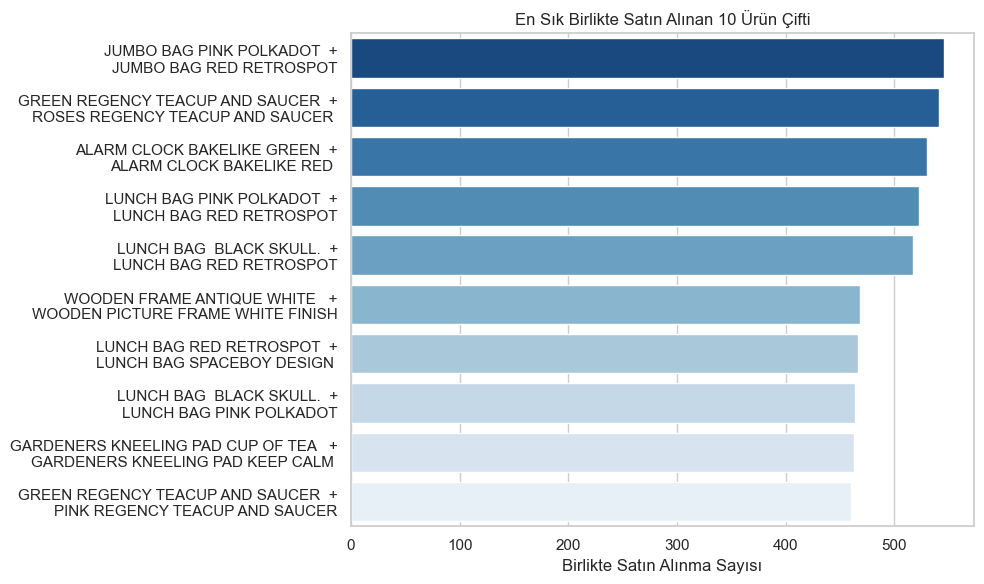

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=pairs_df,
    x='Frekans',
    y='Çift',
    hue='Çift',
    palette='Blues_r',
    legend=False,
    ax=ax
)

ax.set_title('En Sık Birlikte Satın Alınan 10 Ürün Çifti')
ax.set_xlabel('Birlikte Satın Alınma Sayısı')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### S3.2 — Çapraz Satış Yorumu

Birlikte satın alma analizi, hangi ürün çiftlerinin aynı sepette görünme eğiliminde
olduğunu ortaya koymaktadır. Bu bilgi üç operasyonel alanda doğrudan kullanılabilir:

**1. Ürün Yerleşimi**
Sık birlikte satın alınan ürünler e-ticaret arayüzünde "Bununla birlikte alanlar"
bölümünde önerilebilir. Yüksek frekanslı çiftler, öneri algoritmasının başlangıç
kuralları olarak kullanılabilir.

**2. Kampanya Tasarımı**
Yüksek frekanslı çiftler paket (bundle) kampanyalarına dönüştürülebilir.
"İkisini birden al, %10 indirim kazan" gibi teklifler hem ortalama sepet değerini
artırır hem de müşteri için kolaylık sağlar.

**3. Stok Yönetimi**
Birlikte satın alınan ürünlerde eş zamanlı stok açığı müşteri deneyimini olumsuz
etkiler. Bu çiftlerin stok seviyeleri birlikte takip edilmelidir.

> **Önemli not:** Bu analiz yalnızca frekansı ölçmektedir. Daha ileri bir adımda
> Apriori / FP-Growth algoritmaları ile **lift** değeri hesaplanmalıdır. Lift > 1
> olan çiftler tesadüfün ötesinde gerçek bir birliktelik eğilimi taşır.